In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# 设置随机种子，保证结果可复现
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)
print("环境与随机种子已设置。")

环境与随机种子已设置。


In [95]:
class SpikeSortingCAM:
    def __init__(self, capacity=128, bit_width=8):
        """
        基础 CAM 结构
        capacity: 能存多少个神经元模板
        bit_width: 指纹的长度 (例如 8-bit)
        """
        self.capacity = capacity
        self.bit_width = bit_width
        
        # 核心存储
        self.templates = np.zeros((capacity, bit_width), dtype=int)
        self.masks = np.zeros((capacity, bit_width), dtype=int)  # 1=有效, 0=忽略
        self.neuron_ids = np.full(capacity, -1, dtype=int)       # 存每个位置对应的真实 ID
        
    def update_template(self, row_idx, bits, neuron_id=None):
        """写入静态模板"""
        self.templates[row_idx] = np.array(bits)
        self.masks[row_idx] = 1  # 默认全有效
        if neuron_id is not None:
            self.neuron_ids[row_idx] = neuron_id

    def hamming_distance(self, bits1, bits2, mask):
        """计算带 Mask 的汉明距离"""
        # 只比较 Mask 为 1 的位
        diff = np.bitwise_xor(bits1, bits2)
        masked_diff = np.bitwise_and(diff, mask)
        return np.sum(masked_diff)

    def match_spike(self, input_bits, threshold=2):
        """
        核心匹配逻辑
        返回: (匹配到的neuron_id, 匹配到的行号, 最小距离)
        """
        input_arr = np.array(input_bits)
        min_dist = self.bit_width + 1
        best_match_idx = -1
        
        # 遍历所有行寻找最近邻 (Winner-Take-All)
        for i in range(self.capacity):
            if self.neuron_ids[i] == -1: continue # 跳过空行
            
            dist = self.hamming_distance(input_arr, self.templates[i], self.masks[i])
            
            if dist < min_dist:
                min_dist = dist
                best_match_idx = i
        
        # 判断是否满足阈值
        if best_match_idx != -1 and min_dist <= threshold:
            return self.neuron_ids[best_match_idx], best_match_idx, min_dist
        else:
            return None, -1, min_dist

In [ ]:
# 通用 CAM 评测工具封装
# 依赖外部模块 cam_eval.py（在工程根目录）

from cam_eval import build_reference_fingerprints, run_cam_experiment, run_hamming_baseline


def run_cam_suite(
    cam_classes,
    bits_train,
    labels_train,
    bits_test,
    labels_test,
    *,
    capacity=None,
    threshold=2,
    use_dynamic_update=True,
):
    """一键比较多种 CAM 算法在同一份 bits 上的效果。

    参数：
    - cam_classes: 形如 [("Static", SpikeSortingCAM), ("Counter", CounterDynamicCAM), ...]
    - bits_train / labels_train: 训练集（用于生成模板）
    - bits_test / labels_test:   测试集
    - capacity:   CAM capacity（默认 None=按 neuron 数自动给）
    - threshold:  CAM 匹配阈值
    - use_dynamic_update: 是否调用 `match_and_update`（True）或只有静态匹配（False）

    返回：dict[name] = CamExperimentResult
    """
    import numpy as np

    bits_train = np.asarray(bits_train).astype(int)
    bits_test = np.asarray(bits_test).astype(int)
    labels_train = np.asarray(labels_train).astype(int)
    labels_test = np.asarray(labels_test).astype(int)

    # 1) 先根据训练集构造静态模板
    ref_fps = build_reference_fingerprints(bits_train, labels_train)

    results = {}
    for name, cam_cls in cam_classes:
        n_units = len(ref_fps)
        bit_width = bits_train.shape[1]
        cap = capacity if capacity is not None else n_units * 2

        cam_kwargs = dict(capacity=cap, bit_width=bit_width)

        print(f"\n=== Running CAM: {name} ({cam_cls.__name__}) ===")
        res = run_cam_experiment(
            cam_cls,
            cam_kwargs,
            ref_fps,
            bits_test,
            labels_test,
            use_dynamic_update=use_dynamic_update,
            threshold=threshold,
        )
        print(f"Accuracy: {res.accuracy:.4f}")
        results[name] = res

    # 再跑一个纯汉明距离 baseline 方便对比
    print("\n=== Hamming Baseline (no CAM) ===")
    base = run_hamming_baseline(ref_fps, bits_test, labels_test)
    print(f"Accuracy: {base.accuracy:.4f}")
    results["baseline_hamming"] = base

    return results


# 使用示例（伪代码，真正跑时在后面 cell 中填真实变量名）：
#
# from your_cam_module_or_above_cells import (
#     SpikeSortingCAM,
#     CounterDynamicCAM,
#     MarginEmaCAM,
#     ConfidenceWeightedCAM,
#     DualTemplateCAM,
#     ProbabilisticCAM,
#     GrowingCAM,
# )
#
# cam_list = [
#     ("Static", SpikeSortingCAM),
#     ("Counter", CounterDynamicCAM),
#     ("MarginEMA", MarginEmaCAM),
#     ("ConfWeighted", ConfidenceWeightedCAM),
#     ("DualTemplate", DualTemplateCAM),
#     ("ProbCAM", ProbabilisticCAM),
#     ("Growing", GrowingCAM),
# ]
#
# # 无论是 PCA encoder 还是 AE encoder，只要给出这四个数组即可：
# # bits_train, labels_train, bits_test, labels_test
# results = run_cam_suite(
#     cam_list,
#     bits_train,
#     labels_train,
#     bits_test,
#     labels_test,
#     capacity=None,      # 默认=2x 神经元数量
#     threshold=2,
#     use_dynamic_update=True,
# )

In [96]:
class BaseDynamicCAM(SpikeSortingCAM):
    def __init__(self, capacity, bit_width, **kwargs):
        super().__init__(capacity, bit_width)
        # 这里可以接收各种超参数，由子类处理
    
    def initialize_state(self):
        """钩子函数：用于初始化子类需要的额外状态（如计数器、EMA矩阵）"""
        pass

    def _update_policy(self, row_idx, input_bits, dist, threshold):
        """
        【核心抽象方法】
        这里写具体的更新算法。
        子类必须实现这个方法。
        """
        raise NotImplementedError("必须在子类中实现具体的更新策略")

    def match_and_update(self, input_bits, threshold=3):
        """标准流程：匹配 -> (可选)更新 -> 返回"""
        # 1. 匹配
        matched_nid, row_idx, dist = self.match_spike(input_bits, threshold)
        
        # 2. 如果匹配到了，调用具体的更新策略
        if row_idx != -1:
            self._update_policy(row_idx, input_bits, dist, threshold)
            
        return matched_nid, row_idx, dist

    def evaluate_performance(self, test_set, threshold=3, update=False):
        """统一的评估循环"""
        stats = {"correct_hits": 0, "total_known": 0}
        
        for true_id, feature in test_set:
            if update:
                # 动态模式：匹配并允许更新
                matched_id, _, _ = self.match_and_update(feature, threshold=threshold)
            else:
                # 静态模式：仅匹配
                matched_id, _, _ = self.match_spike(feature, threshold=threshold)

            if true_id is not None:
                stats["total_known"] += 1
                if matched_id == true_id:
                    stats["correct_hits"] += 1
        
        acc = (stats["correct_hits"] / stats["total_known"] * 100) if stats["total_known"] > 0 else 0
        return acc

In [97]:
class CounterDynamicCAM(BaseDynamicCAM):
    def __init__(self, capacity, bit_width, max_confidence=10):
        super().__init__(capacity, bit_width)
        self.max_confidence = max_confidence
        self.counters = np.zeros((capacity, bit_width), dtype=int)
    
    def initialize_state(self):
        """初始化计数器为 max_confidence 的一半"""
        initial_val = self.max_confidence // 2
        self.counters = (self.templates * 2 - 1) * initial_val
        self.counters *= self.masks

    def _update_policy(self, row_idx, input_bits, dist, threshold):
        """
        策略：只有匹配了就 +1/-1，满了就翻转
        """
        input_vec = np.array(input_bits)
        # +1 或 -1
        update_dir = (input_vec * 2 - 1)
        
        # 更新并截断
        self.counters[row_idx] = np.clip(
            self.counters[row_idx] + update_dir, 
            -self.max_confidence, 
            self.max_confidence
        )
        
        # 翻转模板
        self.templates[row_idx] = (self.counters[row_idx] > 0).astype(int)

In [98]:
class MarginEmaCAM(BaseDynamicCAM):
    def __init__(self, capacity, bit_width, alpha=0.05):
        super().__init__(capacity, bit_width)
        self.alpha = alpha
        self.ema_templates = np.zeros((capacity, bit_width), dtype=float)

    def initialize_state(self):
        """初始化浮点数 EMA 模板"""
        self.ema_templates = self.templates.astype(float)

    def _update_policy(self, row_idx, input_bits, dist, threshold):
        """
        策略：Margin 限制 + EMA 平滑
        """
        # 1. Margin Check: 只有距离接近阈值边界时才更新 (threshold - dist <= 1)
        margin = threshold - dist
        if margin > 1: 
            return # 匹配得太好了，不需要更新

        # 2. EMA Update
        input_vec = np.array(input_bits)
        self.ema_templates[row_idx] = (
            (1 - self.alpha) * self.ema_templates[row_idx] + 
            self.alpha * input_vec
        )

        # 3. 写回二值模板
        self.templates[row_idx] = (self.ema_templates[row_idx] >= 0.5).astype(int)

In [99]:
class ConfidenceWeightedCAM(BaseDynamicCAM):
    def __init__(self, capacity, bit_width, 
                 lr=0.1, max_conf=5.0):
        super().__init__(capacity, bit_width)
        self.lr = lr
        self.max_conf = max_conf
        self.bit_conf = np.ones((capacity, bit_width), dtype=float)

    def initialize_state(self):
        self.bit_conf[:] = 1.0

    def compute_distance(self, input_bits):
        """
        Weighted Hamming Distance
        """
        input_vec = np.array(input_bits)
        diff = (self.templates != input_vec)
        return np.sum(self.bit_conf * diff, axis=1)

    def _update_policy(self, row_idx, input_bits, dist, threshold):
        margin = threshold - dist
        if margin > 1:
            return  # match 很好，不更新

        input_vec = np.array(input_bits)
        diff = (input_vec != self.templates[row_idx])

        # 1. bit confidence update
        self.bit_conf[row_idx][diff] -= self.lr
        self.bit_conf[row_idx][~diff] += self.lr

        self.bit_conf[row_idx] = np.clip(
            self.bit_conf[row_idx], 0.1, self.max_conf
        )

        # 2. template update（只在低置信度位）
        flip_mask = (
            diff & (self.bit_conf[row_idx] < 1.0)
        )
        self.templates[row_idx][flip_mask] = input_vec[flip_mask]

In [100]:
class DualTemplateCAM(BaseDynamicCAM):
    def __init__(self, capacity, bit_width, alpha=0.1):
        super().__init__(capacity, bit_width)
        self.alpha = alpha
        self.plastic = np.zeros((capacity, bit_width), dtype=float)

    def initialize_state(self):
        self.plastic = self.templates.astype(float)

    def compute_distance(self, input_bits):
        input_vec = np.array(input_bits)
        d_stable = np.sum(self.templates != input_vec, axis=1)
        d_plastic = np.sum(
            (self.plastic >= 0.5).astype(int) != input_vec, axis=1
        )
        return np.minimum(d_stable, d_plastic)

    def _update_policy(self, row_idx, input_bits, dist, threshold):
        input_vec = np.array(input_bits)

        # plastic EMA update
        self.plastic[row_idx] = (
            (1 - self.alpha) * self.plastic[row_idx] +
            self.alpha * input_vec
        )

        # merge to stable if长期一致
        agree = np.abs(self.plastic[row_idx] - self.templates[row_idx]) < 0.1
        self.templates[row_idx][agree] = (
            self.plastic[row_idx][agree] >= 0.5
        ).astype(int)

In [101]:
class ProbabilisticCAM(BaseDynamicCAM):
    def __init__(self, capacity, bit_width, alpha=0.05, eps=1e-4):
        super().__init__(capacity, bit_width)
        self.alpha = alpha
        self.eps = eps
        self.prob = np.full((capacity, bit_width), 0.5, dtype=float)

    def initialize_state(self):
        self.prob = self.templates.astype(float)

    def compute_distance(self, input_bits):
        x = np.array(input_bits)
        p = np.clip(self.prob, self.eps, 1 - self.eps)
        nll = -(
            x * np.log(p) + (1 - x) * np.log(1 - p)
        )
        return np.sum(nll, axis=1)

    def _update_policy(self, row_idx, input_bits, dist, threshold):
        input_vec = np.array(input_bits)
        self.prob[row_idx] = (
            (1 - self.alpha) * self.prob[row_idx] +
            self.alpha * input_vec
        )
        self.templates[row_idx] = (self.prob[row_idx] >= 0.5).astype(int)

In [102]:
class GrowingCAM(BaseDynamicCAM):
    def __init__(self, capacity, bit_width, split_threshold=3):
        super().__init__(capacity, bit_width)
        self.split_threshold = split_threshold
        self.usage = np.zeros(capacity, dtype=int)

    def _update_policy(self, row_idx, input_bits, dist, threshold):
        self.usage[row_idx] += 1

        if dist > threshold and self.free_rows > 0:
            new_idx = self.allocate_row()
            self.templates[new_idx] = np.array(input_bits)
            self.masks[new_idx] = 1

In [103]:
# 1. 读取数据
import json
import numpy as np


df1 = pd.read_csv("/Users/ceker/Library/CloudStorage/OneDrive-TheUniversityofHongKong-Connect/文档/hku/elec4848/code/spike_experiments/experiment_001_u8_bits8_2000s/spike_pca_dataset.csv")
file_path = "/Users/ceker/Library/CloudStorage/OneDrive-TheUniversityofHongKong-Connect/文档/hku/elec4848/code/spike_experiments/experiment_001_u8_bits8_2000s/templates.json"
with open(file_path, 'r') as f:
    data = json.load(f)

# 2. 转换为 reference_fingerprints 字典
# 目标格式: { int_id : np.array([0, 1, ...]) }
reference_fingerprints = {}

for nid_str, bits_list in data.items():
    # json 的键通常是字符串，需要转回 int
    nid = int(nid_str)
    # 将 list 转为 numpy array
    bits = np.array(bits_list, dtype=int)
    reference_fingerprints[nid] = bits


print(reference_fingerprints)
# 3. 准备测试集 (List of tuples)
test_set = []
bit_cols = [f"bit{i}" for i in range(len(next(iter(reference_fingerprints.values()))))]
for _, row in df1.iterrows():
    bits = row[bit_cols].values.astype(int)
    test_set.append((int(row["unit_id"]), bits))
print(test_set[:5])
# 4. 关键：打乱测试集，并模拟一点“漂移” (可选)
random.shuffle(test_set)
print(f"数据加载完毕。测试集样本数: {len(test_set)}")

{0: array([0, 1, 0, 1, 1, 1, 0, 0]), 1: array([0, 0, 0, 1, 0, 0, 0, 1]), 2: array([0, 0, 1, 0, 0, 1, 1, 0]), 3: array([1, 0, 1, 1, 0, 1, 0, 1]), 4: array([1, 0, 1, 1, 0, 0, 1, 0]), 5: array([1, 1, 0, 0, 0, 0, 1, 1]), 6: array([0, 0, 0, 0, 1, 1, 1, 0]), 7: array([0, 1, 1, 0, 0, 0, 0, 0])}
[(0, array([1, 1, 0, 1, 1, 1, 0, 0])), (0, array([1, 1, 0, 1, 0, 1, 0, 1])), (0, array([1, 1, 0, 1, 1, 1, 0, 0])), (0, array([1, 1, 0, 1, 1, 1, 1, 1])), (0, array([1, 1, 0, 1, 0, 1, 0, 0]))]
数据加载完毕。测试集样本数: 47987


=== Dataset Overview (数据集概览) ===
Total Samples (总样本数): 47987
Number of Units (神经元数量): 8
Feature Dimension (指纹位数): 8
----------------------------------------


/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='unit_id', data=dataset, palette='viridis')
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:31: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:31: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:31: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:

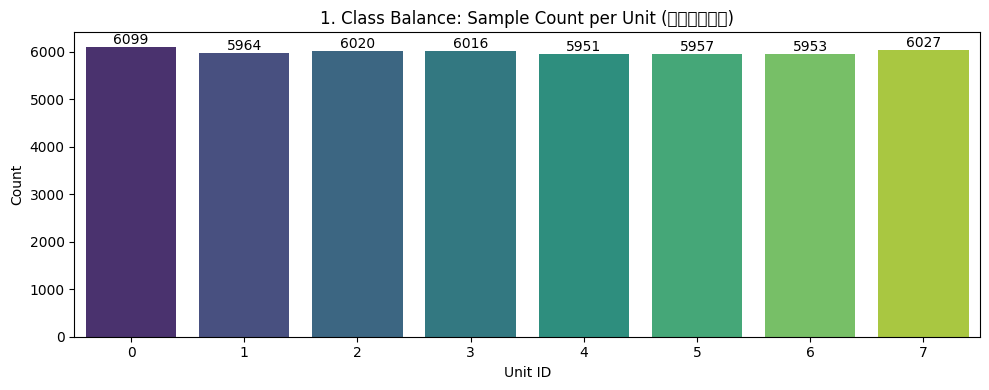

/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:42: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:42: UserWarning: Glyph 32441 (\N{CJK UNIFIED IDEOGRAPH-7EB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:42: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:42: UserWarning: Glyph 31283 (\N{CJK UNIFIED IDEOGRAPH-7A33}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:42: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk1

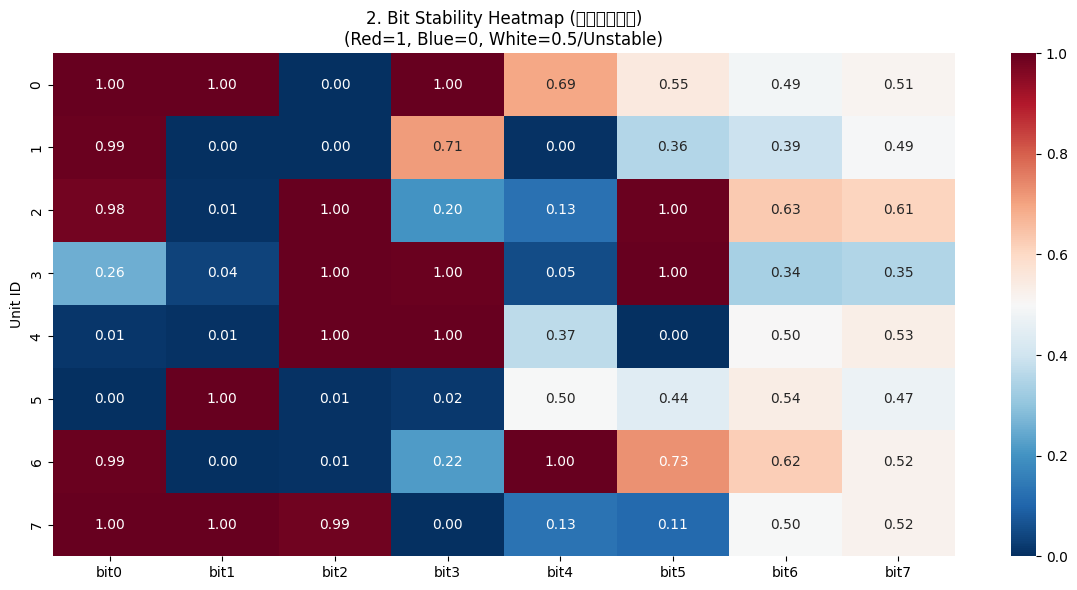

/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:79: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:79: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:79: UserWarning: Glyph 28418 (\N{CJK UNIFIED IDEOGRAPH-6F02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:79: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:79: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk1

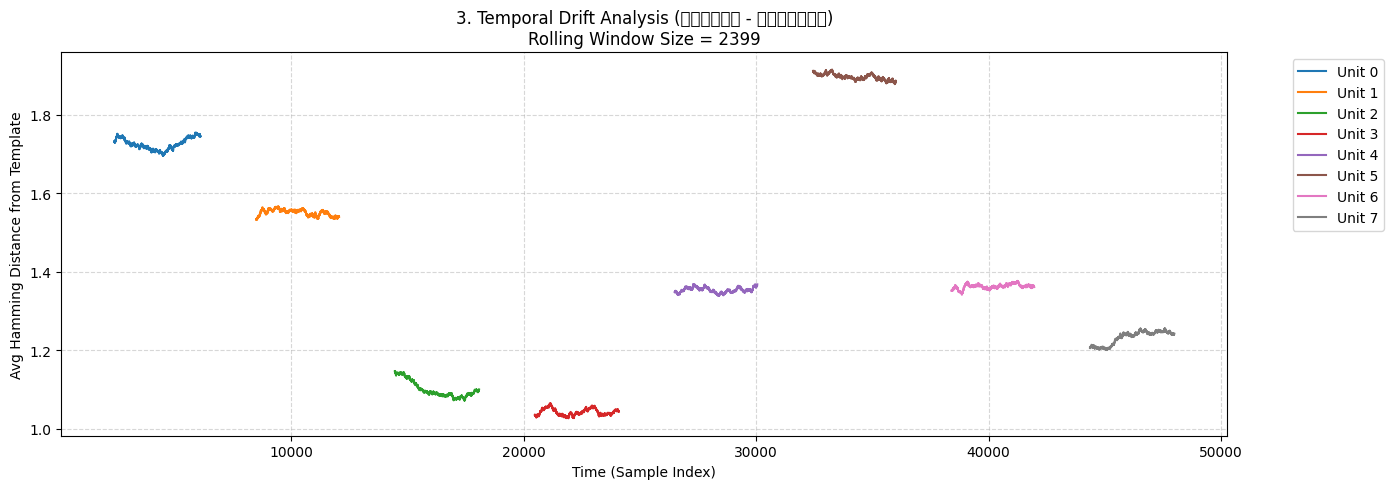

/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:90: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:90: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:90: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:90: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/2142723117.py:90: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/ceker/Library

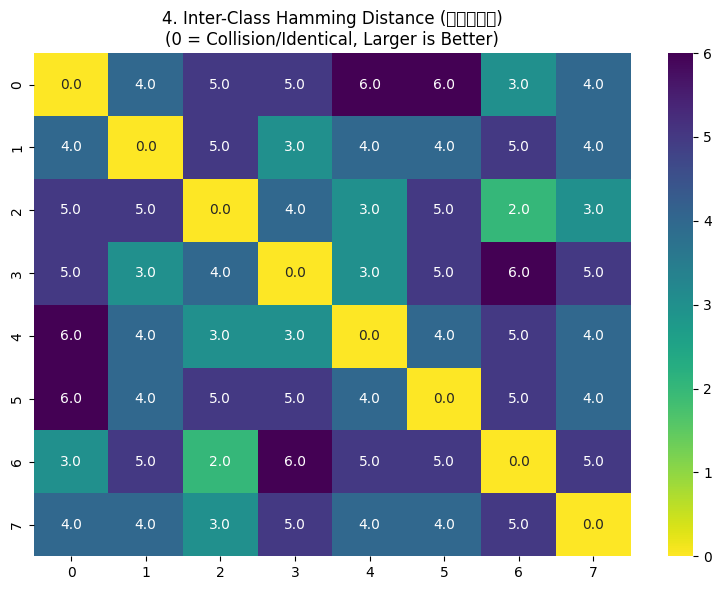


=== Avg Distance to Reference Template ===
       mean       std   count
0  2.759141  1.019178  6099.0
1  2.536888  0.977178  5964.0
2  2.304983  0.879071  6020.0
3  1.831948  0.851030  6016.0
4  2.394219  0.877965  5951.0
5  2.957529  0.972533  5957.0
6  2.389551  0.931523  5953.0
7  2.274764  0.866479  6027.0


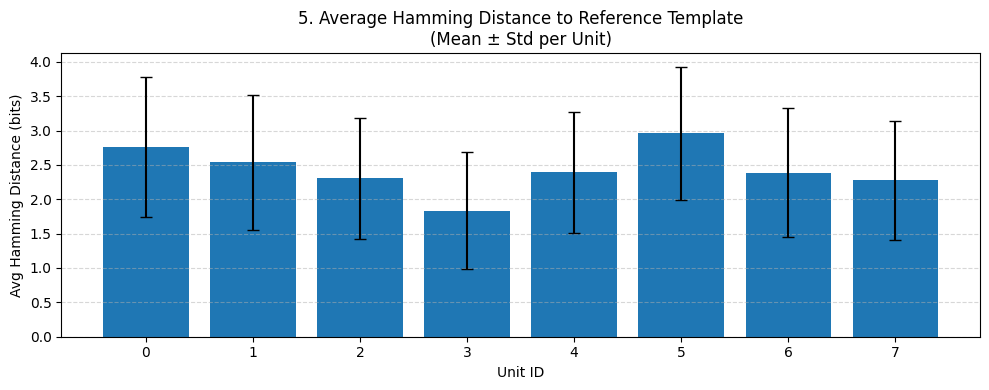


=== Avg Hamming Distance: Unit → Reference ===
          0         1         2         3         4         5         6  \
0  2.759141  4.214789  6.170356  4.117888  4.271848  3.241843  4.784555   
1  4.806841  2.536888  4.458082  2.840040  2.754527  3.193159  4.449363   
2  5.892027  4.930897  2.304983  1.976412  2.928904  4.090698  4.045515   
3  3.853225  3.337267  2.361536  1.831948  2.852560  6.066656  4.249169   
4  4.673164  2.362292  3.418753  3.335406  2.394219  5.311376  4.678373   
5  3.059258  3.992278  4.003525  6.101225  5.847239  2.957529  3.017794   
6  4.202251  4.614480  4.372753  4.154040  4.410885  3.810180  2.389551   
7  5.767712  5.201925  4.053260  4.007798  3.277584  2.211382  5.767546   

          7  
0  5.240203  
1  4.954058  
2  4.544518  
3  3.951629  
4  3.409511  
5  2.956522  
6  6.073912  
7  2.274764  


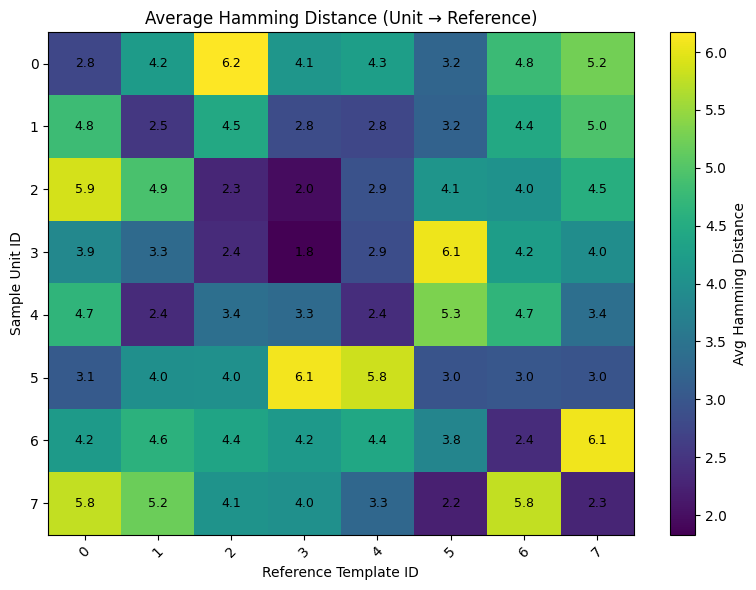

In [104]:
# 分析展示数据集
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

def analyze_spike_dataset(dataset, reference, bit_cols=None):
    """
    数据集特性深度分析函数
    包含：类别平衡性、位稳定性、时间漂移趋势、类间可分性
    """
    if bit_cols is None:
        bit_cols = [c for c in dataset.columns if 'bit' in c]
    
    print(f"=== Dataset Overview (数据集概览) ===")
    print(f"Total Samples (总样本数): {len(dataset)}")
    print(f"Number of Units (神经元数量): {dataset['unit_id'].nunique()}")
    print(f"Feature Dimension (指纹位数): {len(bit_cols)}")
    print("-" * 40)

    # --- 1. 类别平衡性 (Class Balance) ---
    plt.figure(figsize=(10, 4))
    ax = sns.countplot(x='unit_id', data=dataset, palette='viridis')
    plt.title("1. Class Balance: Sample Count per Unit (类别样本分布)")
    plt.xlabel("Unit ID")
    plt.ylabel("Count")
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

    # --- 2. 位稳定性热力图 (Bit Stability Heatmap) ---
    # 计算每个 ID 在每一位上的平均值。接近 0 或 1 表示稳定，接近 0.5 表示噪声大。
    stability_map = dataset.groupby('unit_id')[bit_cols].mean()
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(stability_map, annot=True, cmap="RdBu_r", vmin=0, vmax=1, fmt=".2f")
    plt.title("2. Bit Stability Heatmap (指纹位稳定性)\n(Red=1, Blue=0, White=0.5/Unstable)")
    plt.ylabel("Unit ID")
    plt.tight_layout()
    plt.show()

    # --- 3. 时间漂移分析 (Temporal Drift Analysis) ---
    # 假设数据索引代表时间顺序，计算样本与其所属类别的“理想中心”的距离变化
    
    # 计算每个 ID 的理想模板 (Majority Vote)
    centroids = dataset.groupby('unit_id')[bit_cols].mean().round().astype(int)
    
    # 辅助函数：计算到自己中心的距离
    def get_dist_to_centroid(row):
        uid = row['unit_id']
        centroid = centroids.loc[uid]
        return np.sum(np.abs(row[bit_cols] - centroid))

    df_drift = dataset.copy()
    df_drift['dist'] = df_drift.apply(get_dist_to_centroid, axis=1)
    df_drift['time_idx'] = df_drift.index

    plt.figure(figsize=(14, 5))
    # 自适应窗口大小，用于平滑曲线
    window_size = max(10, len(dataset) // 20)
    
    for uid in sorted(dataset['unit_id'].unique()):
        subset = df_drift[df_drift['unit_id'] == uid]
        if len(subset) > window_size:
            # 滚动平均显示趋势
            rolling = subset['dist'].rolling(window=window_size).mean()
            plt.plot(subset['time_idx'], rolling, label=f'Unit {uid}')
        else:
            plt.scatter(subset['time_idx'], subset['dist'], label=f'Unit {uid} (Scattered)', alpha=0.6)
            
    plt.title(f"3. Temporal Drift Analysis (时间漂移趋势 - 距中心汉明距离)\nRolling Window Size = {window_size}")
    plt.xlabel("Time (Sample Index)")
    plt.ylabel("Avg Hamming Distance from Template")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- 4. 类间距离分析 (Inter-Class Separability) ---
    # 检查不同神经元的理想模板是否长得太像 (Collision Risk)
    dist_matrix = squareform(pdist(centroids.values, metric='hamming')) * len(bit_cols)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(dist_matrix, annot=True, cmap="viridis_r", fmt=".1f",
                xticklabels=centroids.index, yticklabels=centroids.index)
    plt.title("4. Inter-Class Hamming Distance (类间可分性)\n(0 = Collision/Identical, Larger is Better)")
    plt.tight_layout()
    plt.show()

    # --- 5. Average Distance to Reference Template ---
    # 每个 unit 的所有样本，到其 reference 模板的平均汉明距离

    avg_ref_dist = {}

    for uid, group in dataset.groupby('unit_id'):
        if uid not in reference:
            continue  # safety check

        ref_bits = reference[uid]
        dists = []

        for _, row in group.iterrows():
            sample_bits = row[bit_cols].values.astype(int)
            dist = np.sum(sample_bits != ref_bits)
            dists.append(dist)

        avg_ref_dist[uid] = {
            "mean": np.mean(dists),
            "std": np.std(dists),
            "count": len(dists)
        }

    avg_ref_df = (
        pd.DataFrame(avg_ref_dist)
        .T
        .sort_index()
    )

    print("\n=== Avg Distance to Reference Template ===")
    print(avg_ref_df)

    plt.figure(figsize=(10, 4))
    ax = plt.bar(
        avg_ref_df.index.astype(str),
        avg_ref_df["mean"],
        yerr=avg_ref_df["std"],
        capsize=4
    )

    plt.title(
        "5. Average Hamming Distance to Reference Template\n"
        "(Mean ± Std per Unit)"
    )
    plt.xlabel("Unit ID")
    plt.ylabel("Avg Hamming Distance (bits)")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    units = sorted(dataset["unit_id"].unique())
    ref_units = sorted(reference.keys())

    avg_dist_mat = pd.DataFrame(
        index=units,
        columns=ref_units,
        dtype=float
    )

    for u in units:
        group = dataset[dataset["unit_id"] == u]

        samples = group[bit_cols].values.astype(int)

        for r in ref_units:
            ref_bits = reference[r]

            # 对该 unit 的所有样本，算到 ref_r 的距离
            dists = np.sum(samples != ref_bits, axis=1)
            avg_dist_mat.loc[u, r] = dists.mean()

    print("\n=== Avg Hamming Distance: Unit → Reference ===")
    print(avg_dist_mat)

    plt.figure(figsize=(8, 6))
    plt.imshow(avg_dist_mat.values, aspect="auto")
    plt.colorbar(label="Avg Hamming Distance")

    plt.xticks(
        ticks=np.arange(len(ref_units)),
        labels=[str(r) for r in ref_units],
        rotation=45
    )
    plt.yticks(
        ticks=np.arange(len(units)),
        labels=[str(u) for u in units]
    )

    # 数字标注
    for i in range(avg_dist_mat.shape[0]):
        for j in range(avg_dist_mat.shape[1]):
            plt.text(
                j, i,
                f"{avg_dist_mat.iloc[i, j]:.1f}",
                ha="center",
                va="center",
                fontsize=9,
                color="black"
            )

    plt.xlabel("Reference Template ID")
    plt.ylabel("Sample Unit ID")
    plt.title("Average Hamming Distance (Unit → Reference)")
    plt.tight_layout()
    plt.show()






# --- 使用示例 ---
# 假设 df 已经被 pd.read_csv 加载
try:
    analyze_spike_dataset(df1, reference_fingerprints, bit_cols=bit_cols)
except FileNotFoundError:
    print("请确保 spike_pca_dataset.csv 文件存在。")

开始对比实验，共 5 个阈值点...


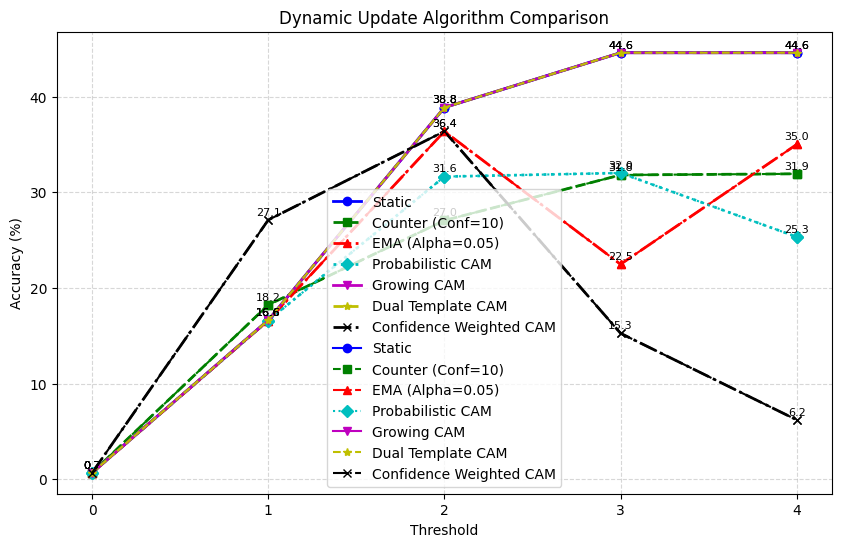

/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45117/1677627585.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


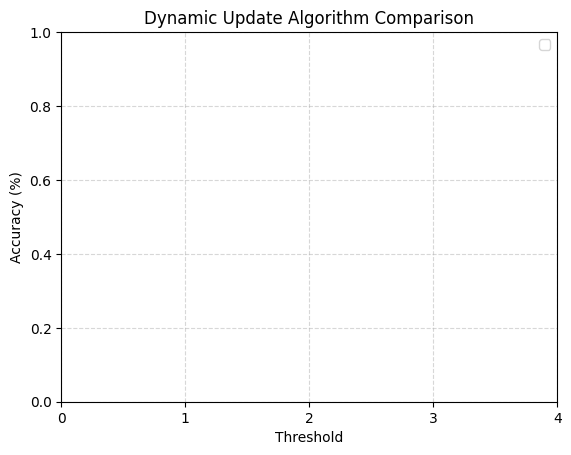

In [105]:
def run_experiment_suite(reference_fingerprints, test_set, thresholds=[0,1,2,3,4]):
    """
    运行完整的对比实验：Static vs Counter vs EMA
    """
    results = {
        "Static": [],
        "Counter (Conf=10)": [],
        "EMA (Alpha=0.05)": [],
        "Probabilistic CAM": [],
        "Growing CAM": [],
        "Dual Template CAM": [],
        "Confidence Weighted CAM": []
    }
    
    print(f"开始对比实验，共 {len(thresholds)} 个阈值点...")
    
    for th in thresholds:
        # --- 1. Static (基准) ---
        # 使用 Base 类即可，update=False

        # --- 2. Counter Dynamic ---
        cam = CounterDynamicCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))), max_confidence=10)
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        cam.initialize_state() # 别忘了初始化计数器
        acc = cam.evaluate_performance(test_set, threshold=th, update=True)
        results["Counter (Conf=10)"].append(acc)

        # --- 3. EMA Dynamic ---
        cam = MarginEmaCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))), alpha=0.05)
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        cam.initialize_state() # 别忘了初始化EMA矩阵
        acc = cam.evaluate_performance(test_set, threshold=th, update=True)
        results["EMA (Alpha=0.05)"].append(acc)

        # --- 4. Probabilistic CAM ---
        cam = ProbabilisticCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))), alpha=0.05)
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        cam.initialize_state() # 别忘了初始化概率矩阵
        acc = cam.evaluate_performance(test_set, threshold=th, update=True)
        results["Probabilistic CAM"].append(acc)

        # --- 5. Growing CAM ---
        cam = GrowingCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))), split_threshold=3)
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        cam.initialize_state() # 别忘了初始化EMA矩阵
        acc = cam.evaluate_performance(test_set, threshold=th, update=True)
        results["Growing CAM"].append(acc)

        # 6. Dual Template CAM
        cam = DualTemplateCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))), alpha=0.1)
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        cam.initialize_state() # 别忘了初始化双模板矩阵
        acc = cam.evaluate_performance(test_set, threshold=th, update=True)
        results["Dual Template CAM"].append(acc)

        # 7. Confidence Weighted CAM
        cam = ConfidenceWeightedCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))), lr=0.1, max_conf=5.0)
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        cam.initialize_state() # 别忘了初始化置信度矩阵
        acc = cam.evaluate_performance(test_set, threshold=th, update=True)
        results["Confidence Weighted CAM"].append(acc)  

        cam = BaseDynamicCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))))
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        acc = cam.evaluate_performance(test_set, threshold=th, update=False)
        results["Static"].append(acc)
    
    return results

# --- 运行并绘图 ---
thresholds = [0, 1, 2, 3, 4]
experiment_results = run_experiment_suite(reference_fingerprints, test_set, thresholds)

# 绘图
plt.figure(figsize=(10, 6))
markers = ['o', 's', '^', 'D', 'v', '*', 'x']  # 7 条线正好对应
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

linestyles = ['-', '--', '-.', ':', '-', '--', '-.']

for i, (name, accs) in enumerate(experiment_results.items()):
    plt.plot(
        thresholds,
        accs,
        marker=markers[i],
        color=colors[i],
        linestyle=linestyles[i],
        label=name,
        linewidth=2
    )

for i, (name, accs) in enumerate(experiment_results.items()):
    plt.plot(thresholds, accs, marker=markers[i], color=colors[i], linestyle=linestyles[i], label=name)
    for x, y in zip(thresholds, accs):
        plt.text(x, y+0.5, f"{y:.1f}", fontsize=8, ha='center')

plt.title("Dynamic Update Algorithm Comparison")
plt.xlabel("Threshold")
plt.ylabel("Accuracy (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(thresholds)
plt.show()

plt.title("Dynamic Update Algorithm Comparison")
plt.xlabel("Threshold")
plt.ylabel("Accuracy (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(thresholds)
plt.show()

🚀 开始对比实验，共 5 个阈值点...
Processing Threshold 4...
✅ 实验完成！

📊 详细准确率结果表 (Accuracy %)
           Static  Counter (Conf=10)  EMA (Alpha=0.05)  Probabilistic CAM  \
Threshold                                                                   
0            0.68               0.68              0.68               0.68   
1           16.63              18.22             16.59              16.59   
2           38.85              27.05             36.36              31.63   
3           44.58              31.80             22.46              32.01   
4           44.58              31.92             34.99              25.33   

           Growing CAM  Dual Template CAM  Confidence Weighted CAM  
Threshold                                                           
0                 0.68               0.68                     0.68  
1                16.63              16.63                    27.10  
2                38.85              38.85                    36.37  
3                44.58             

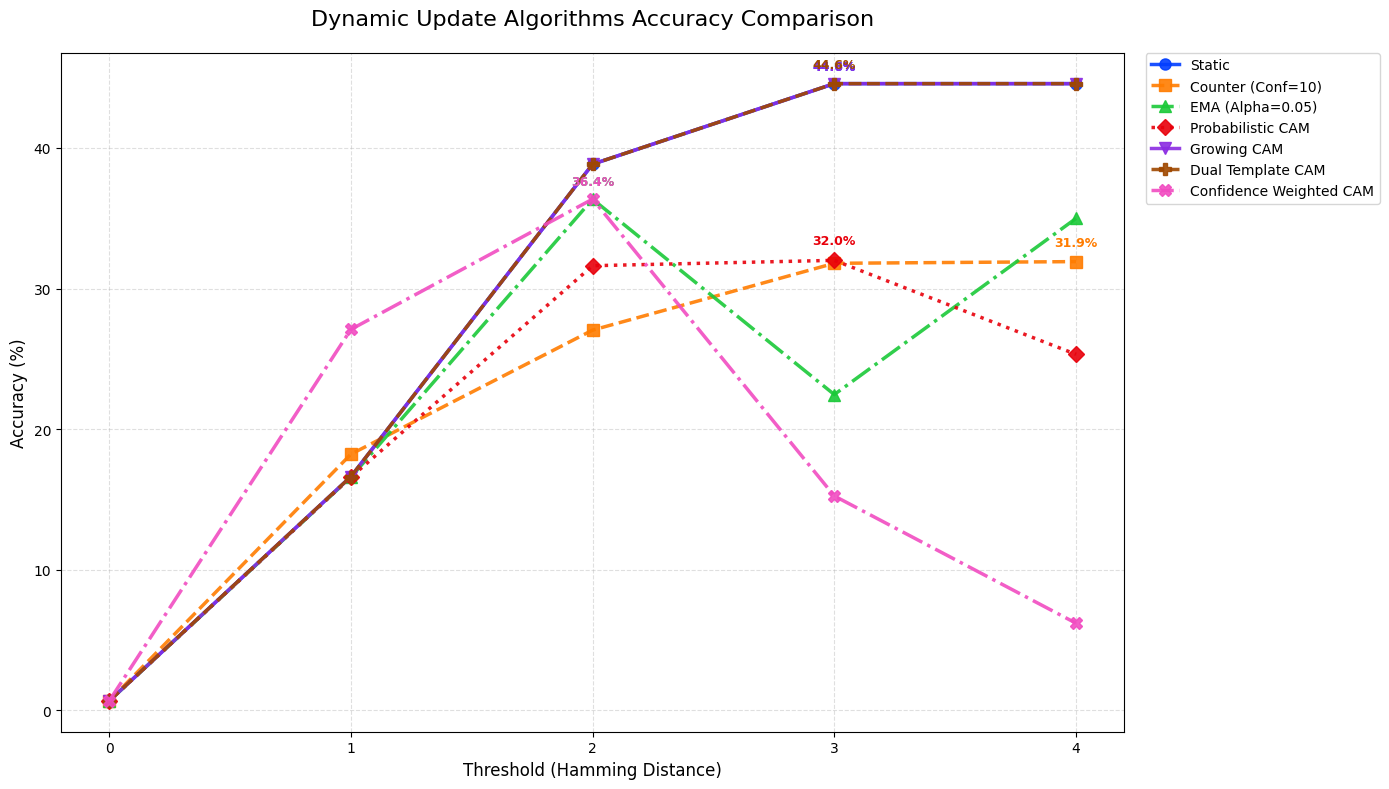

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def run_experiment_suite(reference_fingerprints, test_set, thresholds=[0,1,2,3,4]):
    """
    运行完整的对比实验：Static vs 多种动态更新策略
    """
    # 初始化结果字典
    algorithm_names = [
        "Static",
        "Counter (Conf=10)", 
        "EMA (Alpha=0.05)", 
        "Probabilistic CAM",
        "Growing CAM",
        "Dual Template CAM",
        "Confidence Weighted CAM"
    ]
    results = {name: [] for name in algorithm_names}
    
    print(f"🚀 开始对比实验，共 {len(thresholds)} 个阈值点...")
    
    # 为了进度条显示好看，这里简单print一下
    total_steps = len(thresholds) * len(algorithm_names)
    current_step = 0
    
    for th in thresholds:
        print(f"Processing Threshold {th}...", end="\r")
        
        # --- 1. Static (基准) ---
        cam = BaseDynamicCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))))
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        acc = cam.evaluate_performance(test_set, threshold=th, update=False)
        results["Static"].append(acc)

        # --- 2. Counter Dynamic ---
        cam = CounterDynamicCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))), max_confidence=10)
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        cam.initialize_state() 
        acc = cam.evaluate_performance(test_set, threshold=th, update=True)
        results["Counter (Conf=10)"].append(acc)

        # --- 3. EMA Dynamic ---
        cam = MarginEmaCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))), alpha=0.05)
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        cam.initialize_state()
        acc = cam.evaluate_performance(test_set, threshold=th, update=True)
        results["EMA (Alpha=0.05)"].append(acc)

        # --- 4. Probabilistic CAM ---
        cam = ProbabilisticCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))), alpha=0.05)
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        cam.initialize_state()
        acc = cam.evaluate_performance(test_set, threshold=th, update=True)
        results["Probabilistic CAM"].append(acc)

        # --- 5. Growing CAM ---
        cam = GrowingCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))), split_threshold=3)
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        cam.initialize_state()
        acc = cam.evaluate_performance(test_set, threshold=th, update=True)
        results["Growing CAM"].append(acc)

        # --- 6. Dual Template CAM ---
        cam = DualTemplateCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))), alpha=0.1)
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        cam.initialize_state()
        acc = cam.evaluate_performance(test_set, threshold=th, update=True)
        results["Dual Template CAM"].append(acc)

        # --- 7. Confidence Weighted CAM ---
        cam = ConfidenceWeightedCAM(len(reference_fingerprints), len(next(iter(reference_fingerprints.values()))), lr=0.1, max_conf=5.0)
        for i, (nid, bits) in enumerate(reference_fingerprints.items()):
            cam.update_template(i, bits, int(nid))
        cam.initialize_state()
        acc = cam.evaluate_performance(test_set, threshold=th, update=True)
        results["Confidence Weighted CAM"].append(acc)

    print("\n✅ 实验完成！")
    return results

# ==========================================
# 📊 执行实验与结果展示
# ==========================================
thresholds = [0, 1, 2, 3, 4]
experiment_results = run_experiment_suite(reference_fingerprints, test_set, thresholds)

# --- 1. 打印详细表格 (这是你看具体数字的地方) ---
print("\n" + "="*50)
print("📊 详细准确率结果表 (Accuracy %)")
print("="*50)
# 使用 Pandas 创建表格，行是阈值，列是算法
df_results = pd.DataFrame(experiment_results, index=thresholds)
df_results.index.name = "Threshold"
# 格式化输出，保留2位小数
print(df_results.round(2))
print("="*50 + "\n")

# --- 2. 绘制清晰的折线图 ---
plt.figure(figsize=(14, 8)) # 画布调大一点

# 定义美观的样式
markers = ['o', 's', '^', 'D', 'v', 'P', 'X'] 
colors = sns.color_palette("bright", len(experiment_results)) # 使用 seaborn 的鲜艳配色
linestyles = ['-', '--', '-.', ':', '-', '--', '-.']

# 绘图循环
for i, (name, accs) in enumerate(experiment_results.items()):
    plt.plot(
        thresholds, 
        accs, 
        marker=markers[i % len(markers)], 
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.5, # 线稍微粗一点
        markersize=8,
        label=name,
        alpha=0.9
    )

    # 【关键修改】只在每个算法的"最高准确率"点标数字，避免拥挤
    # 或者只标最后一个点，这里我选择标出每个算法的最高点
    max_acc = max(accs)
    max_idx = accs.index(max_acc)
    best_th = thresholds[max_idx]
    
    # 稍微错开一点标注的位置
    offset = (i % 2) * 1.5 # 奇数行和偶数行错开
    plt.annotate(
        f"{max_acc:.1f}%", 
        xy=(best_th, max_acc),
        xytext=(0, 10 + offset), 
        textcoords="offset points",
        ha='center', 
        fontsize=9,
        fontweight='bold',
        color=colors[i % len(colors)]
    )

plt.title("Dynamic Update Algorithms Accuracy Comparison", fontsize=16, pad=20)
plt.xlabel("Threshold (Hamming Distance)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4) # 网格线淡一点
plt.xticks(thresholds)

# 图例放在外面，或者找个空地放，避免挡住线
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=10)

plt.tight_layout()
plt.show()